# Lab 1: Dynamic Model of a Multi-Link Manipulator (UR5)
## Nagham Sleman  ISO:476937

## 1. Objective
The objective of this lab is to study and analyze the dynamic behavior of a multi-link robotic manipulator using Python and the Robotics Toolbox.  
The UR5 robot is selected as the study case.

# Step 1: Robot Model

The UR5 robot was selected for this study.

The Denavit-Hartenberg parameters were obtained from the toolbox.

In [10]:
import roboticstoolbox as rtb
robot = rtb.models.DH.UR5()
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



### DH Parameters Explanation

Each link is described using:
- θ: joint angle  
- d: link offset  
- a: link length  
- α: link twist  

## Step 2: Dynamic Parameters of the UR5 Robot

The dynamic parameters of the UR5 robot were specified, including:

- Masses of the links  
- Positions of the centers of mass  
- Inertia tensors  
- Motor inertias  
- Viscous friction coefficients  
- Coulomb friction coefficients  
- Gear ratios  
- Joint limits  

The available parameters such as masses and centers of mass were taken from the robot model.  
The remaining parameters were approximated due to the lack of complete data in the datasheet.

### Mass of each link
The mass of each link is specified as follows:

In [11]:
robot.links[0].m = 3.7
robot.links[1].m = 8.393
robot.links[2].m = 2.33
robot.links[3].m = 1.219
robot.links[4].m = 1.219
robot.links[5].m = 0.1897

### Center of mass of each link
The position of the center of mass for each link is defined below:

In [12]:
robot.links[0].r = [0, -0.02561, 0.00193]
robot.links[1].r = [0.2125, 0, 0.11336]
robot.links[2].r = [0.15, 0, 0.0265]
robot.links[3].r = [0, -0.0018, 0.01634]
robot.links[4].r = [0, -0.0018, 0.01634]
robot.links[5].r = [0, 0, -0.001159]

### Inertia tensor of each link
The inertia tensor of each link is approximated as follows:

In [14]:
robot.links[0].I = [0.01, 0.01, 0.01, 0, 0, 0]
robot.links[1].I = [0.02, 0.02, 0.02, 0, 0, 0]
robot.links[2].I = [0.01, 0.01, 0.01, 0, 0, 0]
robot.links[3].I = [0.005, 0.005, 0.005, 0, 0, 0]
robot.links[4].I = [0.005, 0.005, 0.005, 0, 0, 0]
robot.links[5].I = [0.001, 0.001, 0.001, 0, 0, 0]

### Motor inertia
The motor inertia for each joint is defined as:

In [15]:
robot.links[0].Jm = 0.0001
robot.links[1].Jm = 0.0001
robot.links[2].Jm = 0.0001
robot.links[3].Jm = 0.00001
robot.links[4].Jm = 0.00001
robot.links[5].Jm = 0.00001

### Viscous friction coefficients
The viscous friction coefficients are defined as:

In [16]:
robot.links[0].B = 0.001
robot.links[1].B = 0.001
robot.links[2].B = 0.001
robot.links[3].B = 0.0001
robot.links[4].B = 0.0001
robot.links[5].B = 0.0001

### Coulomb friction coefficients
The Coulomb friction values are given as:

In [17]:
robot.links[0].Tc = [0.1, -0.1]
robot.links[1].Tc = [0.1, -0.1]
robot.links[2].Tc = [0.1, -0.1]
robot.links[3].Tc = [0.01, -0.01]
robot.links[4].Tc = [0.01, -0.01]
robot.links[5].Tc = [0.01, -0.01]

### Gear ratios
The gear ratios for each joint are defined as:

In [18]:
robot.links[0].G = 100
robot.links[1].G = 100
robot.links[2].G = 100
robot.links[3].G = 50
robot.links[4].G = 50
robot.links[5].G = 50

### Joint limits
The limits of the generalized coordinates are defined below:

In [ ]:
import numpy as np

robot.links[0].qlim = [-2*np.pi, 2*np.pi]
robot.links[1].qlim = [-2*np.pi, 2*np.pi]
robot.links[2].qlim = [-2*np.pi, 2*np.pi]
robot.links[3].qlim = [-2*np.pi, 2*np.pi]
robot.links[4].qlim = [-2*np.pi, 2*np.pi]
robot.links[5].qlim = [-2*np.pi, 2*np.pi]

## Step 3: Initial and Final Configurations

In this step, arbitrary initial and final joint configurations are defined for the UR5 robot.

The robot is then visualized at both configurations.

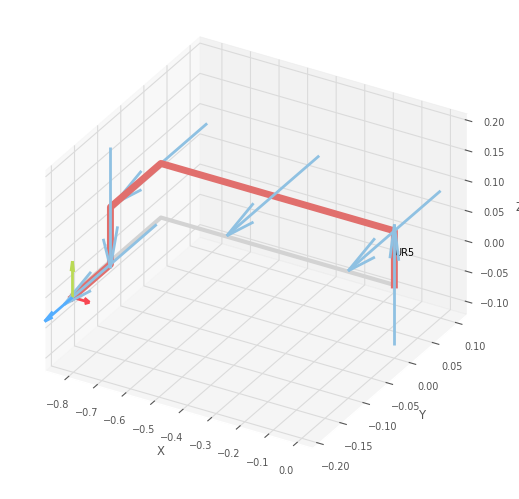

<Figure size 640x480 with 0 Axes>

In [20]:
from math import pi
import matplotlib.pyplot as plt

q_start = [0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

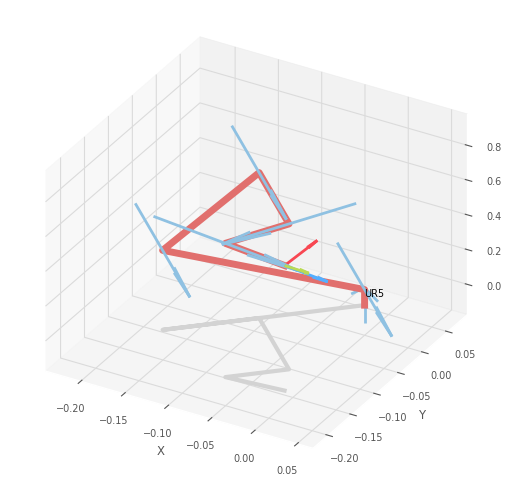

<Figure size 640x480 with 0 Axes>

In [21]:
q_end = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4]
robot.plot(q_end)
plt.show()

wo configurations are defined:

- Initial position:
  q_start = [0, 0, 0, 0, 0, 0]

- Final position:
  q_end = [π/4, -π/3, -π/4, π/3, -π/3, π/4]

The robot is visualized in both configurations using plotting functions.

## Step 4: Plan the trajectory with prebuilt functions

 Plan a trajectory between the initial and final configurations using joint space trajectory.

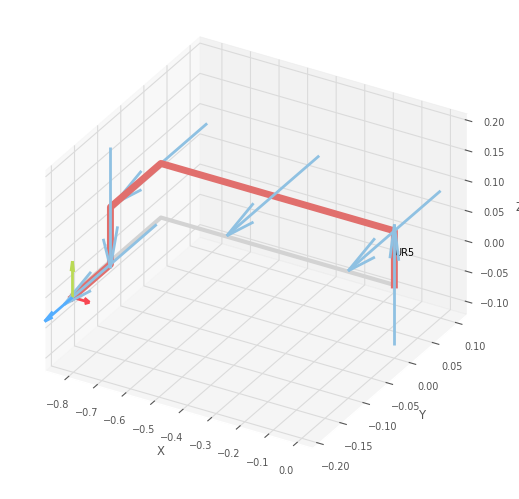

<Figure size 640x480 with 0 Axes>

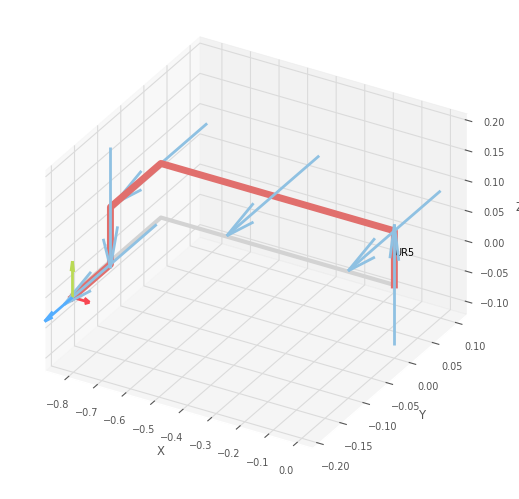

PyPlot3D backend, t = 4.99999999999999, scene:
  robot: Text(0.0, 0.0, 'UR5')

<Figure size 640x480 with 0 Axes>

In [32]:
N = 100
t_start = 0
t_stop = 5
t_step = t_stop / N
time = np.arange(t_start, t_stop, t_step)
tr = rtb.jtraj(q_start, q_end, time) 
# Trajectory using trapezoidal velocity profile (alternative)
tr_m = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)
robot.plot(tr.q)
robot.plot(tr_m.q)

The trajectory between the initial and final configurations is successfully generated using joint space interpolation. 
The robot smoothly moves from the starting configuration to the final configuration as shown in the figure.
### 4.1 jtraj (Polynomial Trajectory)
- Smooth interpolation
- Continuous velocity and acceleration

### 4.2 mtraj (Trapezoidal Trajectory)
- More realistic motion
- Includes acceleration, constant velocity, and deceleration phases

## Step 5: Solve the inverse dynamics

 The Newton–Euler method is used to compute joint torques for three cases:

1. Full dynamics:
   (q̇ ≠ 0, q̈ ≠ 0)

2. Quasi-static case:
   (q̇ ≠ 0, q̈ ≈ 0)

3. Static case:
   (q̇ = 0, q̈ = 0)

The torque is calculated using:
tau = robot.rne(q, qd, qdd)
 

In [36]:
#  non-zero velocities and accelerations
tau = robot.rne(tr.q, tr.qd, tr.qdd).T

# non-zero velocities and negligible accelerations
tau_qs = robot.rne(tr.q, tr.qd, np.zeros([N,6])).T

# zero velocities and accelerations
tau_static = robot.rne(tr.q, np.zeros([N,6]), np.zeros([N,6])).T

#  for mtraj
tau_m = robot.rne(tr_m.q, tr_m.qd, tr_m.qdd).T

The inverse dynamics is computed using the Recursive Newton-Euler method. 
Three cases are considered: full dynamics, quasi-static motion, and static condition. 
The required joint torques differ depending on velocities and accelerations.

## Step 6: Obtain the components of the dynamic equation
The equation of motion is:

                  τ = M(q)q̈ + C(q, q̇)q̇ + G(q)

Where:
- M(q): inertia matrix
- C(q, q̇): Coriolis and centrifugal effects
- G(q): gravity vector

These matrices are computed numerically along the trajectory.

In [37]:
M = robot.inertia(tr.q)
C = robot.coriolis(tr.q, tr.qd)
G = robot.gravload(tr.q)
M0 = robot.inertia(tr.q)
C0 = robot.coriolis(tr.q, np.zeros([N,6]))
G0 = robot.gravload(tr.q)

## Step 7: Obtain the components of the dynamic equation
Plot the joint torques for each link along the trajectory for different dynamic scenarios.

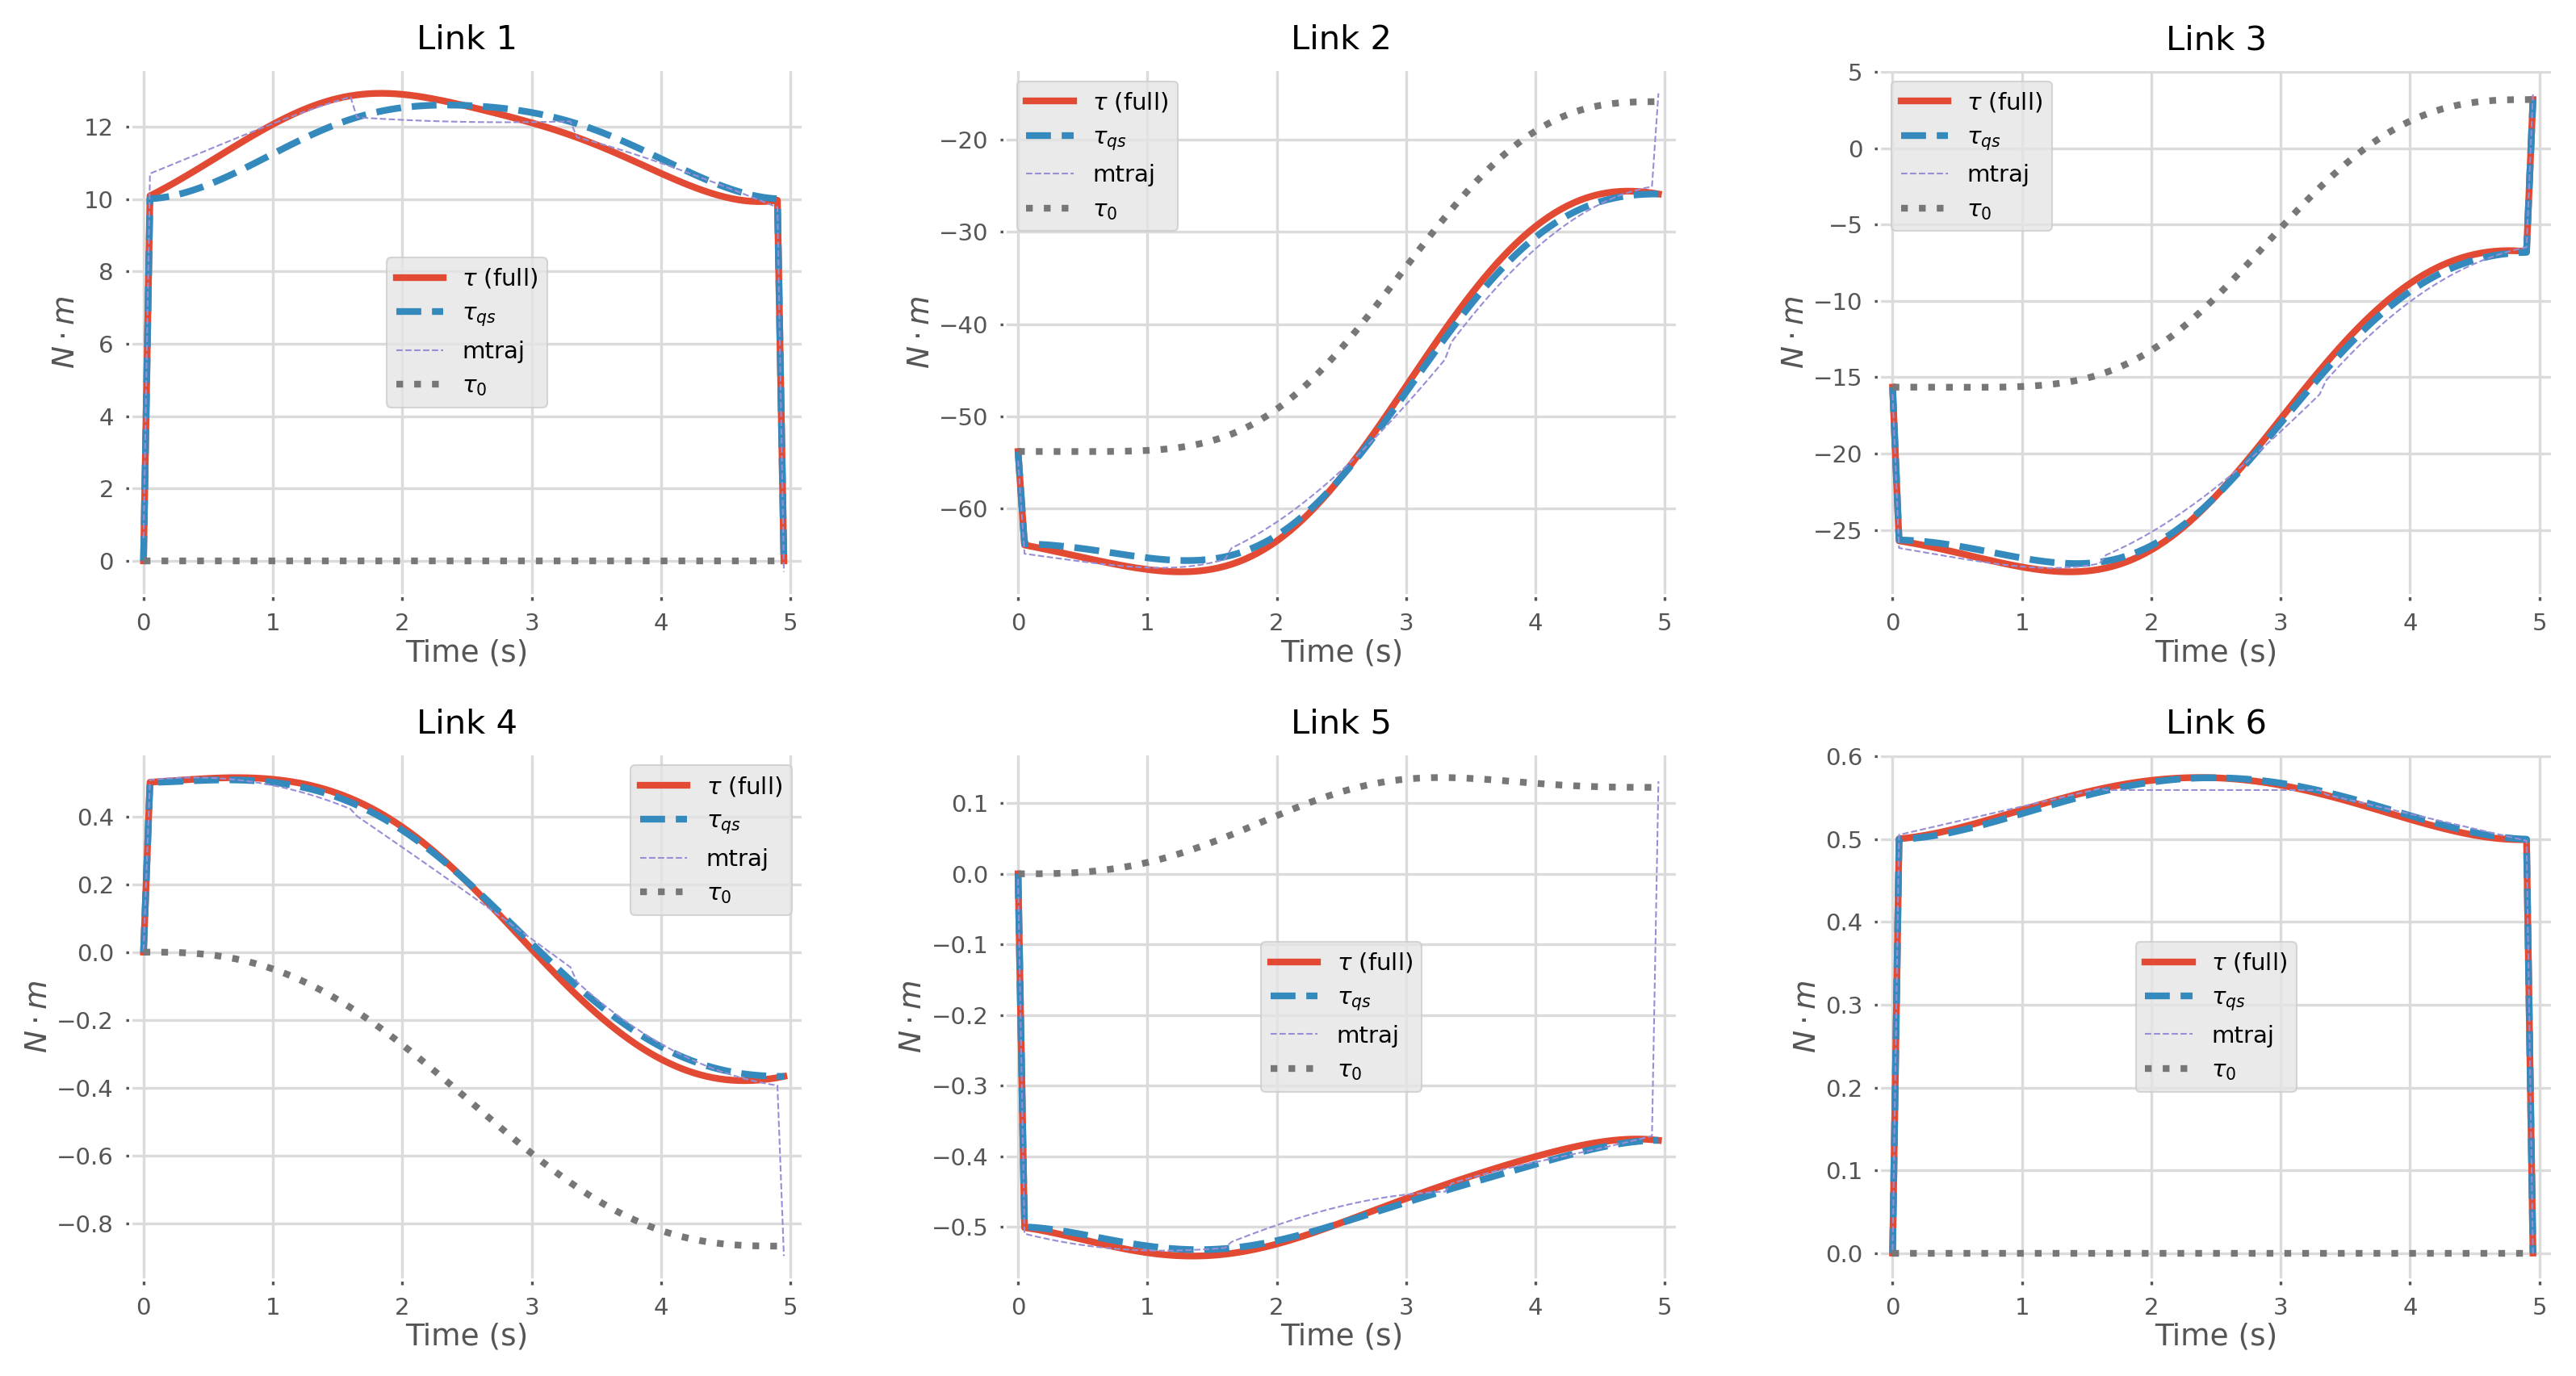

In [38]:
plt.figure(figsize=(10,5), dpi=300)

for g in range(6):
    plt.subplot(2,3,g+1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.3, hspace=0.3)

    
    plt.plot(time, tau[g], linewidth=2, label=r"$\tau$ (full)")

    
    plt.plot(time, tau_qs[g], linewidth=2, linestyle='--', label=r"$\tau_{qs}$")

    # mtraj
    plt.plot(time, tau_m[g], linestyle='--', label="mtraj")
    plt.plot(time, tau_static[g], linewidth=2, linestyle=':', label=r"$\tau_{0}$")

    plt.title(f"Link {g+1}", fontsize=10)
    plt.ylabel(r"$N \cdot m$", fontsize=9)
    plt.xlabel("Time (s)", fontsize=9)

    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1, t_stop+0.1])

plt.show()

- Joint torques change depending on motion conditions.
- Higher torques are observed in joints closer to the base.
- Static case shows only gravity effects.
- Quasi-static case is close to full dynamics when acceleration is small.
- mtraj produces smoother torque profiles than jtraj.

## 9 Conclusion
This lab demonstrates the importance of dynamic modeling in robotics.  
Different trajectories and motion conditions significantly affect torque requirements.

The Newton–Euler method is effective for solving inverse dynamics.  
Using realistic trajectories improves simulation accuracy.